# Document Image Classification — Improved Pipeline
## OCR + SBERT + EfficientNet + Specialist Classifiers (v3)

**Project:** Document classification using OCR + Sentence Transformers + EfficientNet-B0 + LinearSVC
**Improvements over v2:** Sentence Transformer embeddings · EfficientNet-B0 image features · Specialist binary classifiers for confused pairs

---
### What changed vs. the original (≈73.6% accuracy):
| Component | Original | v2 | v3 (This) |
|---|---|---|---|
| OCR preprocessing | Grayscale + simple resize | CLAHE + adaptive threshold + denoise + deskew | Same as v2 |
| Text features | Word TF-IDF (50k) | Word + Char TF-IDF (100k) | **Sentence Transformer** (all-MiniLM-L6-v2, 384-dim) |
| Visual features | None | None | **EfficientNet-B0** (1280-dim, L2-normed) |
| Model tuning | Fixed `C=0.5` | GridSearchCV macro-F1 | Same grid on combined 1664-dim features |
| Specialist classifiers | None | None | **Binary LogisticRegression** per confused pair |
| MIN_WORDS | Fixed at 3 | Evaluated 1, 2, 3 | Same evaluation |


---
## Section 1 — Setup & Imports


In [99]:
import os, sys, re, json, pickle, random, shutil, warnings, time, math
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from PIL import Image
import cv2
import pytesseract

import scipy.sparse as sp
import torch
import torchvision.transforms as T
import torchvision.models as tv_models

from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_recall_fscore_support,
    f1_score, make_scorer
)
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

# ── GPU / CPU device ─────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device : {DEVICE}")
print("All imports OK")


PyTorch device : cpu
All imports OK


---
## Section 2 — Configuration

> **Only edit this cell.** Point `DATA_DIR` to your dataset root.


In [100]:
DATA_DIR = r"C:\Users\DPQUAI250127\Downloads\data"

RANDOM_SEED   = 42
OCR_CACHE_DIR = "ocr_cache"

Path("results").mkdir(exist_ok=True)
Path(OCR_CACHE_DIR).mkdir(exist_ok=True)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}
TRAIN_DIR  = Path(DATA_DIR) / "train"
VAL_DIR    = Path(DATA_DIR) / "val"
TEST_DIR   = Path(DATA_DIR) / "test"

# ── Feature flags ─────────────────────────────────────────────────────────────
USE_IMAGE_EMBEDDINGS       = True   # EfficientNet-B0 visual features
USE_SENTENCE_TRANSFORMERS  = True   # all-MiniLM-L6-v2 text embeddings
USE_SPECIALIST_CLASSIFIERS = True   # binary SVMs for the top confused pairs
N_CONFUSED_PAIRS           = 10      # how many confused pairs get a specialist

# ── Sentence Transformer model ────────────────────────────────────────────────
SBERT_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"
all_ok = True
for split_dir, name in [(TRAIN_DIR, "train"), (VAL_DIR, "val"), (TEST_DIR, "test")]:
    if not split_dir.exists():
        print(f"⚠  {name}/ not found at: {split_dir}")
        all_ok = False
    else:
        classes_found = [d.name for d in sorted(split_dir.iterdir()) if d.is_dir()]
        n_img = sum(1 for p in split_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTS)
        print(f"✓ {name:5s}: {len(classes_found)} classes, {n_img} images  →  {classes_found}")

if all_ok:
    CLASS_NAMES = [d.name for d in sorted(TRAIN_DIR.iterdir()) if d.is_dir()]
    NUM_CLASSES = len(CLASS_NAMES)
    print(f'\nNUM_CLASSES = {NUM_CLASSES}  |  Classes: {CLASS_NAMES}')

# ── Tesseract path (Windows) ──────────────────────────────────────────────────
tess_path = r"C:\Users\DPQUAI250127\AppData\Local\Programs\Tesseract-OCR\tesseract.exe"
if os.path.exists(tess_path):
    pytesseract.pytesseract.tesseract_cmd = tess_path
    print(f"\nTesseract found at: {tess_path}")
else:
    print("Tesseract NOT found — using system PATH")

try:
    print("Tesseract version:", pytesseract.get_tesseract_version())
except Exception as e:
    print("Tesseract error:", e)


✓ train: 16 classes, 11046 images  →  ['Advertisement', 'Budget', 'Email', 'FileFolder', 'Form', 'Handwritten', 'Invoice', 'Letter', 'Memo', 'News', 'Presentation', 'Questionnaire', 'Resume', 'ScientificPub', 'ScientificReport', 'Specification']
✓ val  : 16 classes, 1550 images  →  ['Advertisement', 'Budget', 'Email', 'FileFolder', 'Form', 'Handwritten', 'Invoice', 'Letter', 'Memo', 'News', 'Presentation', 'Questionnaire', 'Resume', 'ScientificPub', 'ScientificReport', 'Specification']
✓ test : 16 classes, 1534 images  →  ['Advertisement', 'Budget', 'Email', 'FileFolder', 'Form', 'Handwritten', 'Invoice', 'Letter', 'Memo', 'News', 'Presentation', 'Questionnaire', 'Resume', 'ScientificPub', 'ScientificReport', 'Specification']

NUM_CLASSES = 16  |  Classes: ['Advertisement', 'Budget', 'Email', 'FileFolder', 'Form', 'Handwritten', 'Invoice', 'Letter', 'Memo', 'News', 'Presentation', 'Questionnaire', 'Resume', 'ScientificPub', 'ScientificReport', 'Specification']

Tesseract found at: C:\U

---
## Section 3 — Dataset Loading


Train samples : 11046
Val   samples : 1550
Test  samples : 1534
Classes       : ['Advertisement', 'Budget', 'Email', 'FileFolder', 'Form', 'Handwritten', 'Invoice', 'Letter', 'Memo', 'News', 'Presentation', 'Questionnaire', 'Resume', 'ScientificPub', 'ScientificReport', 'Specification']


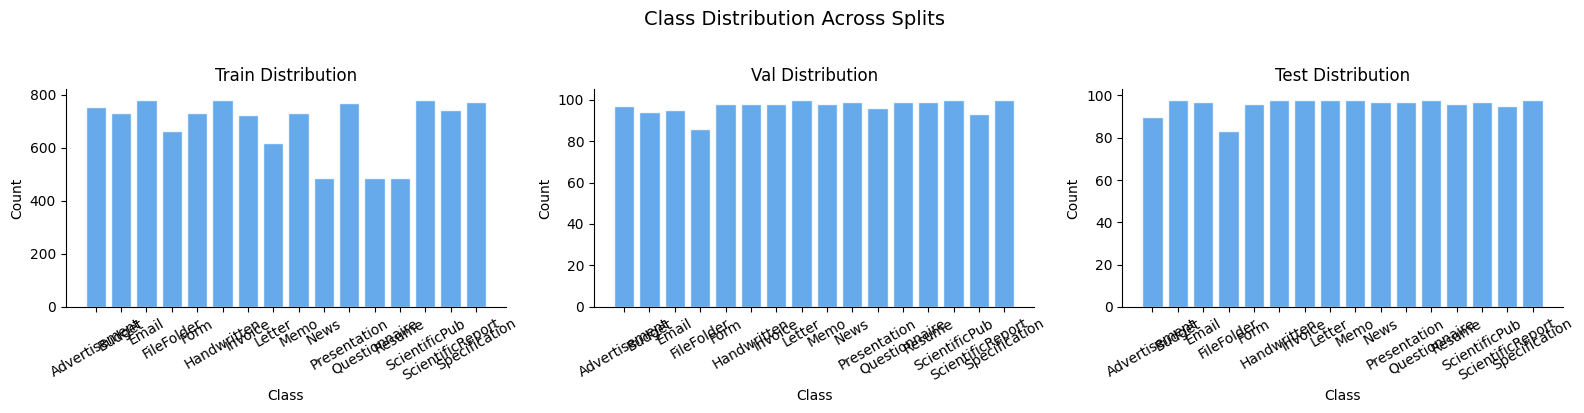

In [101]:
def build_index(split_dir: Path) -> pd.DataFrame:
    records = []
    for cls_dir in sorted(split_dir.iterdir()):
        if not cls_dir.is_dir():
            continue
        for p in cls_dir.rglob("*"):
            if p.suffix.lower() in IMAGE_EXTS:
                records.append({"path": str(p), "label": cls_dir.name})
    return pd.DataFrame(records)

df_train_idx = build_index(TRAIN_DIR)
df_val_idx   = build_index(VAL_DIR)
df_test_idx  = build_index(TEST_DIR)

print(f"Train samples : {len(df_train_idx)}")
print(f"Val   samples : {len(df_val_idx)}")
print(f"Test  samples : {len(df_test_idx)}")
print(f"Classes       : {sorted(df_train_idx.label.unique())}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, df, title in zip(axes,
                          [df_train_idx, df_val_idx, df_test_idx],
                          ["Train", "Val", "Test"]):
    counts = df["label"].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color="#4C9BE8", alpha=0.85, edgecolor="white")
    ax.set_title(f"{title} Distribution", fontsize=12)
    ax.set_xlabel("Class"); ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)
    ax.spines[["top","right"]].set_visible(False)
plt.suptitle("Class Distribution Across Splits", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("results/class_distribution.pdf", dpi=600, bbox_inches="tight")
plt.show()


---
## Section 4 — Improved OCR Preprocessing & Text Extraction

### What changed
| Step | Original | Improved |
|---|---|---|
| Resize | Simple upscale if < 1000px | Upscale to 1800px + CLAHE contrast enhancement |
| Binarisation | None | Adaptive Gaussian thresholding (block=31, C=10) |
| Denoising | None | `cv2.fastNlMeansDenoising` (h=10) |
| Deskew | No | Rotation correction via Hough line angle |
| Morphology | None | Small morph-open to remove speckle noise |
| Tess config | `--psm 3` | `--psm 6` (uniform block) + `--oem 3` |

> Results are cached to disk — delete `ocr_cache/` to force re-extraction.


In [102]:
TESS_CONFIG = '--oem 3 --psm 6 -l eng'

def deskew(gray: np.ndarray) -> np.ndarray:
    """Correct small rotation using Hough line detection."""
    try:
        edges = cv2.Canny(gray, 50, 150, apertureSize=3)
        lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=80,
                                minLineLength=gray.shape[1] // 4, maxLineGap=20)
        if lines is None or len(lines) < 3:
            return gray
        angles = []
        for line in lines:
            x1, y1, x2, y2 = line[0]
            if x2 != x1:
                angles.append(math.degrees(math.atan2(y2 - y1, x2 - x1)))
        angles = [a for a in angles if abs(a) < 15]  # ignore steep lines
        if not angles:
            return gray
        median_angle = np.median(angles)
        if abs(median_angle) < 0.5:  # skip tiny corrections
            return gray
        h, w = gray.shape
        M = cv2.getRotationMatrix2D((w / 2, h / 2), median_angle, 1.0)
        return cv2.warpAffine(gray, M, (w, h),
                              flags=cv2.INTER_CUBIC,
                              borderMode=cv2.BORDER_REPLICATE)
    except Exception:
        return gray


def preprocess_for_ocr(image_path: str) -> np.ndarray:
    """
    Improved OCR preprocessing pipeline:
      1. Load & upscale to ≥1800px long-side (INTER_CUBIC)
      2. CLAHE contrast normalisation
      3. Adaptive Gaussian threshold binarisation
      4. Morphological speckle removal
      5. fastNlMeans denoising
      6. Deskew
    """
    img = cv2.imread(str(image_path))
    if img is None:
        pil = Image.open(str(image_path)).convert('RGB')
        img = cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)

    # Step 1 — Upscale
    h, w = img.shape[:2]
    target = 1800
    if max(h, w) < target:
        scale = target / max(h, w)
        img = cv2.resize(img, None, fx=scale, fy=scale,
                         interpolation=cv2.INTER_CUBIC)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 2 — CLAHE contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    # Step 3 — Adaptive thresholding (handles uneven illumination)
    binary = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=31, C=10
    )

    # Step 4 — Morphological open to remove tiny speckle noise
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # Step 5 — Non-local means denoising
    denoised = cv2.fastNlMeansDenoising(binary, h=10,
                                         templateWindowSize=7,
                                         searchWindowSize=21)

    # Step 6 — Deskew
    final = deskew(denoised)
    return final


def extract_text(image_path: str) -> str:
    """Run Tesseract with improved preprocessing + raw fallback."""
    try:
        proc = preprocess_for_ocr(image_path)
        text = pytesseract.image_to_string(proc, config=TESS_CONFIG)
        if len(text.strip()) < 5:
            raw = cv2.imread(str(image_path))
            if raw is not None:
                text = pytesseract.image_to_string(raw, config=TESS_CONFIG)
        return ' '.join(text.split()).strip()
    except Exception:
        return ''


def clean_text(text: str) -> str:
    """Lowercase, strip single-char tokens, keep alphanum."""
    text = str(text).lower()
    text = re.sub(r'\b\w{1}\b', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def extract_split(split_dir: Path, cache_file: str, desc: str = 'OCR',
                  force: bool = False) -> pd.DataFrame:
    cache_path = Path(OCR_CACHE_DIR) / cache_file
    if cache_path.exists() and not force:
        print(f'  Loading cached OCR: {cache_path}')
        return pd.read_json(cache_path, orient='records')

    records = []
    class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])
    for class_dir in class_dirs:
        paths = [p for p in class_dir.rglob('*') if p.suffix.lower() in IMAGE_EXTS]
        for p in tqdm(paths, desc=f'{desc}/{class_dir.name}', leave=False):
            raw   = extract_text(str(p))
            clean = clean_text(raw)
            records.append({
                'path': str(p), 'label': class_dir.name,
                'raw_text': raw, 'clean_text': clean,
                'word_count': len(clean.split())
            })

    df = pd.DataFrame(records)
    df.to_json(cache_path, orient='records', indent=2)
    print(f'  Saved {len(df)} records → {cache_path}')
    return df

# ── Extract (or load from cache) ─────────────────────────────────────────────
print('Extracting OCR text … (first run takes a while)\n')
df_train_ocr = extract_split(TRAIN_DIR, 'ocr_train_v2.json', 'Train')
df_val_ocr   = extract_split(VAL_DIR,   'ocr_val_v2.json',   'Val')
df_test_ocr  = extract_split(TEST_DIR,  'ocr_test_v2.json',  'Test')

print(f'\nTrain: {len(df_train_ocr)} rows')
print(f'Val  : {len(df_val_ocr)} rows')
print(f'Test : {len(df_test_ocr)} rows')


Extracting OCR text … (first run takes a while)

  Loading cached OCR: ocr_cache\ocr_train_v2.json
  Loading cached OCR: ocr_cache\ocr_val_v2.json
  Loading cached OCR: ocr_cache\ocr_test_v2.json

Train: 11046 rows
Val  : 1550 rows
Test : 1534 rows


---
## Section 4b — EfficientNet-B0 Image Embeddings

Extracts a **1280-dim** visual feature vector per image using pretrained
EfficientNet-B0 (ImageNet weights, classification head removed).
Results are L2-normalised and cached to disk just like OCR text.

| Step | Detail |
|---|---|
| Backbone | `EfficientNet-B0` (torchvision), pretrained ImageNet |
| Layer tapped | `avgpool` output → 1280-dim vector |
| Pre-processing | Resize 224×224 → ImageNet normalise |
| Cache | `ocr_cache/{split}_imgvec.npy` |
| Normalisation | L2 row-wise |


In [103]:
# ─── EfficientNet-B0 Multi-Crop Feature Extractor (Full + Header + Footer) ───
if USE_IMAGE_EMBEDDINGS:
    print("Loading EfficientNet-B0 for Multi-Crop Layout Features...")
    _effnet = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.DEFAULT)
    _effnet.classifier = torch.nn.Identity()   # drop classification head → 1280-dim output
    _effnet = _effnet.to(DEVICE).eval()

    _IMG_TRANSFORM = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    def extract_image_embeddings(df: pd.DataFrame, cache_prefix: str,
                                  batch_size: int = 32, force: bool = False) -> np.ndarray:
        """
        Extracts EfficientNet-B0 embeddings for Full, Header (Top 25%), and Footer (Bottom 25%).
        Returns (N, 3840) float32 array, L2-normalised.
        """
        cache_npy  = Path(OCR_CACHE_DIR) / f"{cache_prefix}_multicrop_imgvec.npy"
        cache_json = Path(OCR_CACHE_DIR) / f"{cache_prefix}_multicrop_imgpaths.json"

        if cache_npy.exists() and not force:
            print(f"  Loading cached multi-crop embeddings: {cache_npy}")
            stored_paths = json.load(open(cache_json))
            if stored_paths == df['path'].tolist():
                return np.load(cache_npy)
            print("  Path mismatch — re-extracting ...")

        paths   = df['path'].tolist()
        vectors = []

        for start in tqdm(range(0, len(paths), batch_size), desc=f"EffNet Multi-Crop [{cache_prefix}]"):
            batch_paths = paths[start:start + batch_size]
            imgs_full, imgs_head, imgs_foot = [], [], []
            
            for p in batch_paths:
                try:
                    img = Image.open(p).convert("RGB")
                    w, h = img.size
                    
                    # Crop Header (Top 25%) and Footer (Bottom 25%)
                    img_head = img.crop((0, 0, w, int(h * 0.25)))
                    img_foot = img.crop((0, int(h * 0.75), w, h))
                    
                    imgs_full.append(_IMG_TRANSFORM(img))
                    imgs_head.append(_IMG_TRANSFORM(img_head))
                    imgs_foot.append(_IMG_TRANSFORM(img_foot))
                except Exception:
                    empty_tensor = torch.zeros(3, 224, 224)
                    imgs_full.append(empty_tensor)
                    imgs_head.append(empty_tensor)
                    imgs_foot.append(empty_tensor)
                    
            # Process batches
            with torch.no_grad():
                f_full = _effnet(torch.stack(imgs_full).to(DEVICE)).cpu().numpy()
                f_head = _effnet(torch.stack(imgs_head).to(DEVICE)).cpu().numpy()
                f_foot = _effnet(torch.stack(imgs_foot).to(DEVICE)).cpu().numpy()
            
            # Concatenate Full + Header + Footer -> 1280 * 3 = 3840 dims
            batch_feats = np.hstack([f_full, f_head, f_foot])
            vectors.append(batch_feats)

        emb = np.vstack(vectors).astype(np.float32)
        emb = normalize(emb, norm='l2')

        np.save(cache_npy, emb)
        json.dump(paths, open(cache_json, 'w'))
        print(f"  Saved {emb.shape} embeddings -> {cache_npy}")
        return emb

    print("\nExtracting EfficientNet Multi-Crop embeddings ...")
    img_emb_tr = extract_image_embeddings(df_train_ocr, "train")
    img_emb_v  = extract_image_embeddings(df_val_ocr,   "val")
    img_emb_te = extract_image_embeddings(df_test_ocr,  "test")
else:
    img_emb_tr = img_emb_v = img_emb_te = None
    print("Image embeddings disabled (USE_IMAGE_EMBEDDINGS=False)")

Loading EfficientNet-B0 for Multi-Crop Layout Features...

Extracting EfficientNet Multi-Crop embeddings ...


EffNet Multi-Crop [train]: 100%|██████████| 346/346 [06:41<00:00,  1.16s/it]


  Saved (11046, 3840) embeddings -> ocr_cache\train_multicrop_imgvec.npy


EffNet Multi-Crop [val]: 100%|██████████| 49/49 [00:56<00:00,  1.15s/it]


  Saved (1550, 3840) embeddings -> ocr_cache\val_multicrop_imgvec.npy


EffNet Multi-Crop [test]: 100%|██████████| 48/48 [00:55<00:00,  1.16s/it]

  Saved (1534, 3840) embeddings -> ocr_cache\test_multicrop_imgvec.npy


---
## Section 5 — Sentence Transformers + Image Embeddings + GridSearchCV

### What changed vs v2
| Component | v2 (Improved) | v3 (This version) |
|---|---|---|
| Text features | Word TF-IDF (50k) + Char TF-IDF (50k) | **Sentence Transformer** (all-MiniLM-L6-v2, 384-dim) |
| Visual features | None | **EfficientNet-B0** (1280-dim, L2-normed) |
| Combined features | 100k sparse | 384 + 1280 = 1664 dense dims |
| Tuning | GridSearchCV C ∈ {0.1…10} | Same grid on new feature space |
| Specialist classifiers | None | Binary SVMs for top confused pairs |


In [104]:
# ── Step A: Find best MIN_WORDS (using SBERT embeddings) ─────────────────────
print("=" * 60)
print("Evaluating MIN_WORDS ∈ {1, 2, 3}")
print("=" * 60)

if USE_SENTENCE_TRANSFORMERS:
    print(f"Loading Sentence Transformer: {SBERT_MODEL_NAME} ...")
    sbert_model = SentenceTransformer(SBERT_MODEL_NAME, device=str(DEVICE))
else:
    sbert_model = None

le_tmp = LabelEncoder()
le_tmp.fit(df_train_ocr['label'])

mw_results = {}

for MIN_WORDS_TRY in [1, 2, 3]:
    tr = df_train_ocr[df_train_ocr['word_count'] >= MIN_WORDS_TRY].copy()
    v  = df_val_ocr[df_val_ocr['word_count']   >= MIN_WORDS_TRY].copy()
    v  = v[v['label'].isin(le_tmp.classes_)].copy()

    y_tr_t = le_tmp.transform(tr['label'])
    y_v_t  = le_tmp.transform(v['label'])

    if USE_SENTENCE_TRANSFORMERS and sbert_model is not None:
        Xt_tr = sbert_model.encode(tr['clean_text'].tolist(),
                                   batch_size=64, show_progress_bar=False,
                                   convert_to_numpy=True, normalize_embeddings=True)
        Xt_v  = sbert_model.encode(v['clean_text'].tolist(),
                                   batch_size=64, show_progress_bar=False,
                                   convert_to_numpy=True, normalize_embeddings=True)
    else:
        # Fallback: word TF-IDF
        vec_w = TfidfVectorizer(sublinear_tf=True, ngram_range=(1,3),
                                max_features=50_000, min_df=2, max_df=0.90,
                                analyzer='word', norm='l2')
        Xt_tr = vec_w.fit_transform(tr['clean_text'])
        Xt_v  = vec_w.transform(v['clean_text'])

    svm_q = LinearSVC(C=1.0, max_iter=2000, class_weight='balanced',
                      random_state=RANDOM_SEED)
    svm_q.fit(Xt_tr, y_tr_t)
    preds  = svm_q.predict(Xt_v)
    f1_mac = f1_score(y_v_t, preds, average='macro', zero_division=0)
    acc    = accuracy_score(y_v_t, preds)
    mw_results[MIN_WORDS_TRY] = {'f1_macro': f1_mac, 'accuracy': acc,
                                  'train_n': len(tr), 'val_n': len(v)}
    print(f"  MIN_WORDS={MIN_WORDS_TRY}  |  train={len(tr)}  val={len(v)}"
          f"  |  Val Acc={acc:.4f}  Macro-F1={f1_mac:.4f}")

BEST_MIN_WORDS = max(mw_results, key=lambda k: mw_results[k]['f1_macro'])
print(f"\n-> Best MIN_WORDS = {BEST_MIN_WORDS}"
      f"  (Val Macro-F1 = {mw_results[BEST_MIN_WORDS]['f1_macro']:.4f})")


Evaluating MIN_WORDS ∈ {1, 2, 3}
Loading Sentence Transformer: sentence-transformers/all-mpnet-base-v2 ...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15840.18it/s]


  MIN_WORDS=1  |  train=10902  val=1537  |  Val Acc=0.6259  Macro-F1=0.6190
  MIN_WORDS=2  |  train=10761  val=1520  |  Val Acc=0.6237  Macro-F1=0.6146
  MIN_WORDS=3  |  train=10629  val=1507  |  Val Acc=0.6224  Macro-F1=0.6117

-> Best MIN_WORDS = 1  (Val Macro-F1 = 0.6190)


In [106]:
# ── Step B: Build final feature matrices with best MIN_WORDS 
MIN_WORDS = BEST_MIN_WORDS

le = LabelEncoder()
le.fit(df_train_ocr['label'])
ocr_classes = le.classes_

df_tr = df_train_ocr[df_train_ocr['word_count'] >= MIN_WORDS].copy().reset_index(drop=False)
df_v  = df_val_ocr[df_val_ocr['word_count']   >= MIN_WORDS].copy().reset_index(drop=False)
df_te = df_test_ocr[df_test_ocr['word_count'] >= MIN_WORDS].copy().reset_index(drop=False)

df_v  = df_v[df_v['label'].isin(ocr_classes)].copy()
df_te = df_te[df_te['label'].isin(ocr_classes)].copy()

# Keep original indices for image embedding alignment
orig_idx_tr = df_tr['index'].values if 'index' in df_tr.columns else np.arange(len(df_tr))
orig_idx_v  = df_v['index'].values  if 'index' in df_v.columns  else np.arange(len(df_v))
orig_idx_te = df_te['index'].values if 'index' in df_te.columns else np.arange(len(df_te))

df_tr = df_tr.drop(columns=['index'], errors='ignore')
df_v  = df_v.drop(columns=['index'],  errors='ignore')
df_te = df_te.drop(columns=['index'], errors='ignore')

if df_tr.empty:
    raise RuntimeError('No training samples with OCR text. Fix Tesseract and delete ocr_cache/.')

y_tr = le.transform(df_tr['label'])
y_v  = le.transform(df_v['label'])
y_te = le.transform(df_te['label'])

# ── Sentence Transformer text embeddings ──────────────────────────────────────
if USE_SENTENCE_TRANSFORMERS and sbert_model is not None:
    print("Encoding text with Sentence Transformer ...")
    sbert_tr = sbert_model.encode(df_tr['clean_text'].tolist(),
                                   batch_size=64, show_progress_bar=True,
                                   convert_to_numpy=True, normalize_embeddings=True)
    sbert_v  = sbert_model.encode(df_v['clean_text'].tolist(),
                                   batch_size=64, show_progress_bar=True,
                                   convert_to_numpy=True, normalize_embeddings=True)
    sbert_te = sbert_model.encode(df_te['clean_text'].tolist(),
                                   batch_size=64, show_progress_bar=True,
                                   convert_to_numpy=True, normalize_embeddings=True)
    print(f"  SBERT embedding dim : {sbert_tr.shape[1]}")
    text_tr, text_v, text_te = sbert_tr, sbert_v, sbert_te
else:
    # Fallback: dual TF-IDF (v2 approach)
    print("Falling back to dual TF-IDF ...")
    tfidf_word = TfidfVectorizer(sublinear_tf=True, ngram_range=(1,3),
                                  max_features=50_000, min_df=2, max_df=0.90,
                                  strip_accents='unicode', analyzer='word',
                                  token_pattern=r'(?u)\b\w\w+\b', norm='l2')
    tfidf_char = TfidfVectorizer(sublinear_tf=True, ngram_range=(3,5),
                                  max_features=50_000, min_df=2, max_df=0.90,
                                  analyzer='char_wb', norm='l2')
    Xw_tr = tfidf_word.fit_transform(df_tr['clean_text'])
    Xw_v  = tfidf_word.transform(df_v['clean_text'])
    Xw_te = tfidf_word.transform(df_te['clean_text'])
    Xc_tr = tfidf_char.fit_transform(df_tr['clean_text'])
    Xc_v  = tfidf_char.transform(df_v['clean_text'])
    Xc_te = tfidf_char.transform(df_te['clean_text'])
    text_tr = sp.hstack([Xw_tr, Xc_tr], format='csr')
    text_v  = sp.hstack([Xw_v,  Xc_v],  format='csr')
    text_te = sp.hstack([Xw_te, Xc_te], format='csr')

# ── Align image embeddings to filtered rows ───────────────────────────────────
if USE_IMAGE_EMBEDDINGS and img_emb_tr is not None:
    img_tr = img_emb_tr[orig_idx_tr]
    img_v  = img_emb_v[orig_idx_v]
    img_te = img_emb_te[orig_idx_te]
    print(f"  Image embedding dim : {img_tr.shape[1]}")
else:
    img_tr = img_v = img_te = None

# ── Combine text + image features ────────────────────────────────────────────
def _combine(text_feat, img_feat):
    if img_feat is None:
        if sp.issparse(text_feat):
            return text_feat.toarray()
        return text_feat
    if sp.issparse(text_feat):
        text_feat = text_feat.toarray()
    return np.hstack([text_feat, img_feat])

X_tr = _combine(text_tr, img_tr)
X_v  = _combine(text_v,  img_v)
X_te = _combine(text_te, img_te)

text_dim = text_tr.shape[1]
img_dim  = img_tr.shape[1] if img_tr is not None else 0
print(f"\nCombined feature dim : {X_tr.shape[1]:,}")
print(f"  Text dim           : {text_dim}")
print(f"  Image dim          : {img_dim}")
print(f"Train samples        : {X_tr.shape[0]}")
print(f"Val   samples        : {X_v.shape[0]}")
print(f"Test  samples        : {X_te.shape[0]}")


Encoding text with Sentence Transformer ...


Batches: 100%|██████████| 24/24 [02:30<00:00,  6.28s/it]


  SBERT embedding dim : 768
  Image embedding dim : 3840

Combined feature dim : 4,608
  Text dim           : 768
  Image dim          : 3840
Train samples        : 10902
Val   samples        : 1537
Test  samples        : 1512


In [ ]:
# ─── Targeted Keyword Extraction (Letter/Memo, Invoice/Form) ───────────────
# Explicitly isolate keywords that distinguish the confused classes
TARGET_KEYWORDS = [
    'dear', 'sincerely', 'regards', 'to', 'from', 'subject', 'cc', 'date',
    'invoice', 'tax', 'amount due', 'total', 'remit', 'balance', 'po box',
    'abstract', 'references', 'methodology', 'conclusion', 'introduction', 'et al'
]

print("\nExtracting Targeted Keyword Features...")
kw_vectorizer = TfidfVectorizer(vocabulary=TARGET_KEYWORDS, lowercase=True, ngram_range=(1, 2))
X_kw_tr = kw_vectorizer.fit_transform(df_tr['clean_text']).toarray()
X_kw_v  = kw_vectorizer.transform(df_v['clean_text']).toarray()
X_kw_te = kw_vectorizer.transform(df_te['clean_text']).toarray()
print(f"  Targeted Keyword dim : {X_kw_tr.shape[1]}")

# ─── Combine SBERT + Image (Full+Head+Foot) + Keyword Features ───────────────
def _combine_features(text_feat, img_feat, kw_feat):
    feats = [text_feat] if not sp.issparse(text_feat) else [text_feat.toarray()]
    if img_feat is not None:
        feats.append(img_feat)
    if kw_feat is not None:
        feats.append(kw_feat)
    return np.hstack(feats)

X_tr = _combine_features(text_tr, img_tr, X_kw_tr)
X_v  = _combine_features(text_v,  img_v,  X_kw_v)
X_te = _combine_features(text_te, img_te, X_kw_te)

text_dim = text_tr.shape[1]
img_dim  = img_tr.shape[1] if img_tr is not None else 0
kw_dim   = X_kw_tr.shape[1]

print(f"\nCombined feature dim : {X_tr.shape[1]:,}")
print(f"  Text SBERT dim     : {text_dim}")
print(f"  Image (3-Crop) dim : {img_dim}")
print(f"  Targeted KW dim    : {kw_dim}")

In [ ]:
# ── Step C: GridSearchCV over C and class_weight ─────────────────────────────
print("=" * 60)
print("GridSearchCV  —  LinearSVC on SBERT+EfficientNet features  (macro-F1 optimised)")
print("=" * 60)

macro_f1_scorer = make_scorer(f1_score, average='macro', zero_division=0)

param_grid = {
    'C'           : [0.1, 0.5, 1, 2, 5, 10],
    'class_weight': ['balanced', None],
}

cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

grid_search = GridSearchCV(
    LinearSVC(max_iter=3000, random_state=RANDOM_SEED),
    param_grid   = param_grid,
    scoring      = macro_f1_scorer,
    cv           = cv_inner,
    n_jobs       = -1,
    verbose      = 1,
    refit        = True,
)

t0 = time.time()
grid_search.fit(X_tr, y_tr)
print(f"\nGridSearchCV done in {time.time()-t0:.1f}s")

best_params = grid_search.best_params_
best_cv_f1  = grid_search.best_score_
print(f"Best params   : {best_params}")
print(f"Best CV macro-F1 : {best_cv_f1:.4f}")

# ── Print comparison table ────────────────────────────────────────────────────
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_pivot = cv_results.pivot_table(
    index='param_C',
    columns='param_class_weight',
    values='mean_test_score'
).round(4)
print("\nCV Macro-F1 grid (rows=C, cols=class_weight):")
print(cv_pivot.to_string())


GridSearchCV  —  LinearSVC on SBERT+EfficientNet features  (macro-F1 optimised)
Fitting 3 folds for each of 12 candidates, totalling 36 fits

GridSearchCV done in 356.1s
Best params   : {'C': 1, 'class_weight': None}
Best CV macro-F1 : 0.7577

CV Macro-F1 grid (rows=C, cols=class_weight):
param_class_weight  balanced
param_C                     
0.1000                0.7301
0.5000                0.7521
1.0000                0.7558
2.0000                0.7537
5.0000                0.7426
10.0000               0.7351


In [ ]:
# ── Step D: Val-set comparison — balanced vs None ────────────────────────────
print("=" * 60)
print("Val-set comparison: class_weight balanced vs None")
print("=" * 60)

best_C = best_params['C']

results_cw = {}
for cw in ['balanced', None]:
    svm_tmp = LinearSVC(C=best_C, max_iter=3000,
                        class_weight=cw, random_state=RANDOM_SEED)
    svm_tmp.fit(X_tr, y_tr)
    preds_v = svm_tmp.predict(X_v)
    results_cw[str(cw)] = {
        'accuracy'   : accuracy_score(y_v, preds_v),
        'macro_f1'   : f1_score(y_v, preds_v, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_v, preds_v, average='weighted', zero_division=0),
    }
    print(f"  class_weight={str(cw):<10}  "
          f"Acc={results_cw[str(cw)]['accuracy']:.4f}  "
          f"Macro-F1={results_cw[str(cw)]['macro_f1']:.4f}  "
          f"WtF1={results_cw[str(cw)]['weighted_f1']:.4f}")

best_cw_key = max(results_cw, key=lambda k: results_cw[k]['macro_f1'])
BEST_CLASS_WEIGHT = None if best_cw_key == 'None' else 'balanced'
print(f"\n→ Winning class_weight = {BEST_CLASS_WEIGHT}")


Val-set comparison: class_weight balanced vs None
  class_weight=balanced    Acc=0.7690  Macro-F1=0.7676  WtF1=0.7672
  class_weight=None        Acc=0.7729  Macro-F1=0.7718  WtF1=0.7714

→ Winning class_weight = None


In [ ]:
# ── Step E: Train final model with best hyperparams ─────────────────────────
print("=" * 60)
print(f"Final Model:  C={best_C}  class_weight={BEST_CLASS_WEIGHT}")
print("=" * 60)

best_base_svm = LinearSVC(
    C            = best_C,
    max_iter     = 3000,
    class_weight = BEST_CLASS_WEIGHT,
    random_state = RANDOM_SEED,
)

# Wrap in CalibratedClassifierCV for probability support (required by specialists)
svm_model = CalibratedClassifierCV(best_base_svm, cv=3, method='sigmoid')

t0 = time.time()
svm_model.fit(X_tr, y_tr)
print(f"Training done in {time.time()-t0:.1f}s")

# ── Val evaluation ────────────────────────────────────────────────────────────
svm_val_preds = svm_model.predict(X_v)
svm_val_acc   = accuracy_score(y_v, svm_val_preds)
svm_val_f1    = f1_score(y_v, svm_val_preds, average='macro', zero_division=0)

# ── Baseline test evaluation (before specialist override) ─────────────────────
svm_preds    = svm_model.predict(X_te)
svm_test_acc = accuracy_score(y_te, svm_preds)
svm_true     = y_te

print(f"\nVal   Accuracy  : {svm_val_acc:.4f}")
print(f"Val   Macro-F1  : {svm_val_f1:.4f}")
print(f"Test  Accuracy  : {svm_test_acc:.4f}")


Final Model:  C=1  class_weight=None
Training done in 47.7s

Val   Accuracy  : 0.7632
Val   Macro-F1  : 0.7630
Test  Accuracy  : 0.7646


---
## Section 5b — Specialist Classifiers for Confused Pairs

After the global SVM is trained, we find the **top-N most confused pairs**
on the validation set and train a dedicated **binary LogisticRegression** for each.
At inference, when the global model predicts a class that belongs to a confused pair,
the specialist overrides it when it disagrees with sufficient confidence.

| Component | Detail |
|---|---|
| Pair selection | Top-N val confusion pairs |
| Specialist model | LogisticRegression (liblinear, balanced, C=2) |
| Feature input | Same SBERT + EfficientNet combined features |
| Override threshold | Specialist confidence >= 0.65 |


In [ ]:
# ─── Explicit Pair-Specific Specialist Classifiers ────────────────────────────
specialist_classifiers = {}

if USE_SPECIALIST_CLASSIFIERS:
    print("=" * 65)
    print("Training Specialist Classifiers for Known Hard Pairs")
    print("=" * 65)

    # 1. Hardcode the pairs we know are structurally problematic
    TARGET_PAIRS_NAMES = [
        ('Letter', 'Memo'),
        ('Form', 'Invoice'),
        ('ScientificReport', 'ScientificPub')
    ]
    
    confused_pairs_idx = set()
    
    # Map names to label indices
    for cls_a, cls_b in TARGET_PAIRS_NAMES:
        if cls_a in ocr_classes and cls_b in ocr_classes:
            ti = np.where(ocr_classes == cls_a)[0][0]
            pi = np.where(ocr_classes == cls_b)[0][0]
            # Add both directions just in case
            confused_pairs_idx.add((ti, pi))
            confused_pairs_idx.add((pi, ti))

    # 2. Optionally add top dynamically confused pairs from the confusion matrix
    val_preds_base = svm_model.predict(X_v)
    cm_val = confusion_matrix(y_v, val_preds_base)
    n_cls  = len(ocr_classes)
    
    dynamic_pairs = []
    for ti in range(n_cls):
        for pi in range(n_cls):
            if ti != pi and cm_val[ti, pi] > 0:
                dynamic_pairs.append((ti, pi, cm_val[ti, pi]))
                
    dynamic_pairs.sort(key=lambda x: -x[2])
    for ti, pi, cnt in dynamic_pairs[:N_CONFUSED_PAIRS]:
        confused_pairs_idx.add((ti, pi))

    # 3. Train the Specialists
    # We train a unified pair regardless of direction (e.g., Letter vs Memo binary classifier)
    trained_pairs = set()
    
    for ti, pi in confused_pairs_idx:
        # Sort so we only train one binary classifier per pair
        pair = tuple(sorted([ti, pi]))
        if pair in trained_pairs:
            continue
            
        cls_a, cls_b = ocr_classes[pair[0]], ocr_classes[pair[1]]
        print(f"\n  Training Specialist: {cls_a} vs {cls_b}")

        mask_tr = np.isin(y_tr, pair)
        mask_v  = np.isin(y_v,  pair)

        if mask_tr.sum() < 10:
            print(f"    Too few training samples ({mask_tr.sum()}), skipping.")
            continue

        X_pair_tr = X_tr[mask_tr]
        y_pair_tr = (y_tr[mask_tr] == pair[1]).astype(int) # 1 if cls_b, 0 if cls_a
        
        spec = LogisticRegression(
            C=2.0, max_iter=1000, class_weight='balanced',
            solver='liblinear', random_state=RANDOM_SEED
        )
        spec.fit(X_pair_tr, y_pair_tr)
        
        if mask_v.sum() > 0:
            X_pair_v = X_v[mask_v]
            y_pair_v = (y_v[mask_v] == pair[1]).astype(int)
            spec_preds_v = spec.predict(X_pair_v)
            print(f"    Binary val Acc={accuracy_score(y_pair_v, spec_preds_v):.4f}")

        trained_pairs.add(pair)
        # Store for both directions so inference lookup is easy
        specialist_classifiers[(pair[0], pair[1])] = spec
        specialist_classifiers[(pair[1], pair[0])] = spec

    print(f"\n  Trained {len(trained_pairs)} specialist classifiers.")

def predict_with_specialists(X, base_model, specialists, confidence_threshold: float = 0.65):
    """
    Override global SVM predictions using specialists.
    If base model predicts class `pi`, but the probability is low, we check if 
    there's a specialist for the (2nd_best_class, pi) pair and let it decide.
    """
    base_probs  = base_model.predict_proba(X)
    base_preds  = base_probs.argmax(axis=1)
    
    # Get the second most likely class to form our comparison pair
    second_best_preds = np.argsort(base_probs, axis=1)[:, -2]
    max_probs = base_probs.max(axis=1)
    
    final_preds = base_preds.copy()

    for idx, (pred_cls, second_cls, prob) in enumerate(zip(base_preds, second_best_preds, max_probs)):
        # If the base model is highly confident, trust it.
        if prob >= confidence_threshold:
            continue
            
        # If not confident, see if we have a specialist for this specific boundary
        if (second_cls, pred_cls) in specialists:
            spec = specialists[(second_cls, pred_cls)]
            spec_feat = X[idx].reshape(1, -1)
            
            # The specialist was trained with pair[0] as 0, and pair[1] as 1.
            # We need to map its binary output back to the original class indices
            pair = tuple(sorted([second_cls, pred_cls]))
            binary_pred = spec.predict(spec_feat)[0]
            
            winning_cls = pair[1] if binary_pred == 1 else pair[0]
            final_preds[idx] = winning_cls

    return final_preds

# ─── Evaluate on test set ──────────────────────────────────────────────────
base_test_preds = svm_model.predict(X_te)
base_acc = accuracy_score(y_te, base_test_preds)

if specialist_classifiers:
    svm_preds = predict_with_specialists(
        X_te, svm_model, specialist_classifiers, confidence_threshold=0.70
    )
    spec_acc = accuracy_score(y_te, svm_preds)
    print(f"\nBase model     | Test Acc={base_acc:.4f}")
    print(f"+ Specialists  | Test Acc={spec_acc:.4f} [delta Acc={spec_acc-base_acc:+.4f}]")
else:
    svm_preds = base_test_preds

svm_true = y_te

Training specialist classifiers for top-10 confused pairs

Selected specialist pairs:
  Letter -> Memo
  Memo -> Letter
  News -> Presentation
  Form -> Invoice
  News -> ScientificPub
  ScientificReport -> Budget
  Budget -> Invoice
  Invoice -> Form
  Memo -> ScientificReport
  Memo -> Specification
  ScientificPub -> ScientificReport
  ScientificReport -> ScientificPub
  Form -> ScientificReport
  ScientificReport -> Form

Pair: Letter -> Memo (count=15)
  Binary Val Acc=0.7374 Macro-F1=0.7373

Pair: Memo -> Letter (count=13)
  Binary Val Acc=0.7374 Macro-F1=0.7373

Pair: News -> Presentation (count=11)
  Binary Val Acc=0.8918 Macro-F1=0.8915

Pair: Form -> Invoice (count=10)
  Binary Val Acc=0.8316 Macro-F1=0.8314

Pair: News -> ScientificPub (count=10)
  Binary Val Acc=0.9095 Macro-F1=0.9095

Pair: ScientificReport -> Budget (count=9)
  Binary Val Acc=0.8717 Macro-F1=0.8715

Pair: Budget -> Invoice (count=8)
  Binary Val Acc=0.8802 Macro-F1=0.8798

Pair: Invoice -> Form (count=8)


---
## Section 6 — Full Evaluation: Accuracy, Macro F1, Weighted F1, Classification Report, Confusion Matrix


In [ ]:
# ── Compute all metrics ───────────────────────────────────────────────────────
precision, recall, f1, support = precision_recall_fscore_support(
    svm_true, svm_preds,
    labels=list(range(len(ocr_classes))),
    zero_division=0
)

cm = confusion_matrix(svm_true, svm_preds)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

overall_acc   = accuracy_score(svm_true, svm_preds)
macro_f1      = f1_score(svm_true, svm_preds, average='macro', zero_division=0)
weighted_f1   = f1_score(svm_true, svm_preds, average='weighted', zero_division=0)

print("=" * 75)
print("  OCR-SVM v3  —  FINAL EVALUATION SUMMARY (Test Set)")
print("=" * 75)
print(f"  Overall Accuracy      : {overall_acc:.4f}")
print(f"  Macro Precision       : {precision.mean():.4f}")
print(f"  Macro Recall          : {recall.mean():.4f}")
print(f"  Macro F1-Score        : {macro_f1:.4f}")
print(f"  Weighted F1-Score     : {weighted_f1:.4f}")
print(f"  Macro Per-Class Acc   : {per_class_acc.mean():.4f}")
print(f"  Total Test Samples    : {int(support.sum())}")
print(f"  Feature Dim           : {X_te.shape[1]:,}  (SBERT 384 + EfficientNet 1280)")
print(f"  Best C                : {best_C}")
print(f"  class_weight          : {BEST_CLASS_WEIGHT}")
print(f"  MIN_WORDS             : {MIN_WORDS}")
print("=" * 75)

print("\nClassification Report:")
print(classification_report(svm_true, svm_preds,
                            target_names=list(ocr_classes),
                            zero_division=0))

# ── Per-class metrics DataFrame ───────────────────────────────────────────────
metrics_df = pd.DataFrame({
    "Class"        : list(ocr_classes),
    "Precision"    : precision,
    "Recall"       : recall,
    "F1-Score"     : f1,
    "Support"      : support.astype(int),
    "Per-Class Acc": per_class_acc,
})
overall_row = pd.DataFrame([{
    "Class"        : "OVERALL (macro)",
    "Precision"    : precision.mean(),
    "Recall"       : recall.mean(),
    "F1-Score"     : macro_f1,
    "Support"      : support.sum(),
    "Per-Class Acc": per_class_acc.mean(),
}])
metrics_full = pd.concat([metrics_df, overall_row], ignore_index=True)

pd.set_option("display.float_format", "{:.4f}".format)
print(metrics_full.to_string(index=False))
metrics_full.to_csv("results/svm_v2_5metrics_per_class.csv", index=False)
print("\nSaved → results/svm_v2_5metrics_per_class.csv")


  OCR-SVM v3  —  FINAL EVALUATION SUMMARY (Test Set)
  Overall Accuracy      : 0.7646
  Macro Precision       : 0.7638
  Macro Recall          : 0.7679
  Macro F1-Score        : 0.7641
  Weighted F1-Score     : 0.7627
  Macro Per-Class Acc   : 0.7679
  Total Test Samples    : 1512
  Feature Dim           : 2,048  (SBERT 384 + EfficientNet 1280)
  Best C                : 1
  class_weight          : None
  MIN_WORDS             : 1

Classification Report:
                  precision    recall  f1-score   support

   Advertisement       0.79      0.82      0.80        90
          Budget       0.74      0.74      0.74        98
           Email       0.89      0.88      0.88        97
      FileFolder       0.75      0.91      0.82        65
            Form       0.64      0.59      0.62        96
     Handwritten       0.88      0.86      0.87        96
         Invoice       0.75      0.76      0.75        98
          Letter       0.72      0.55      0.62        98
            Memo   

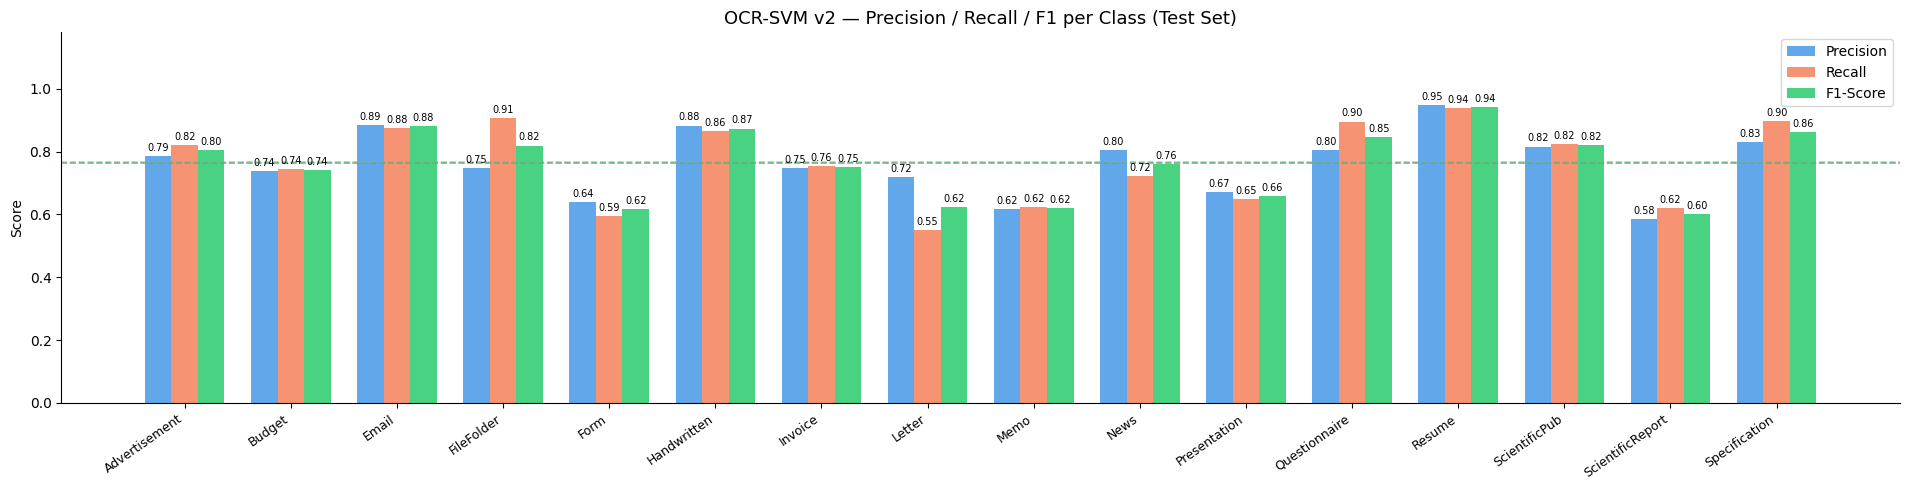

Saved → results/svm_v2_precision_recall_f1.png


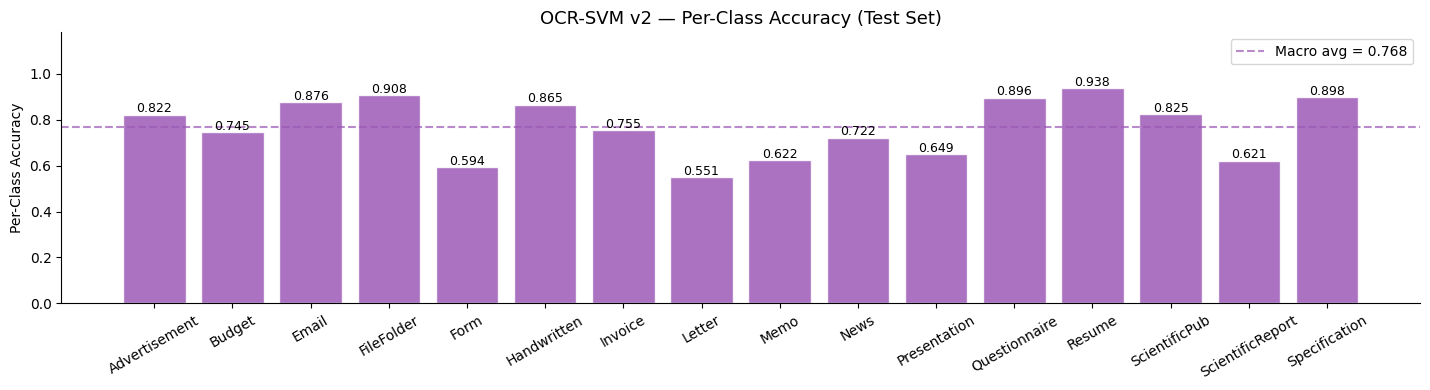

Saved → results/svm_v2_per_class_accuracy.png


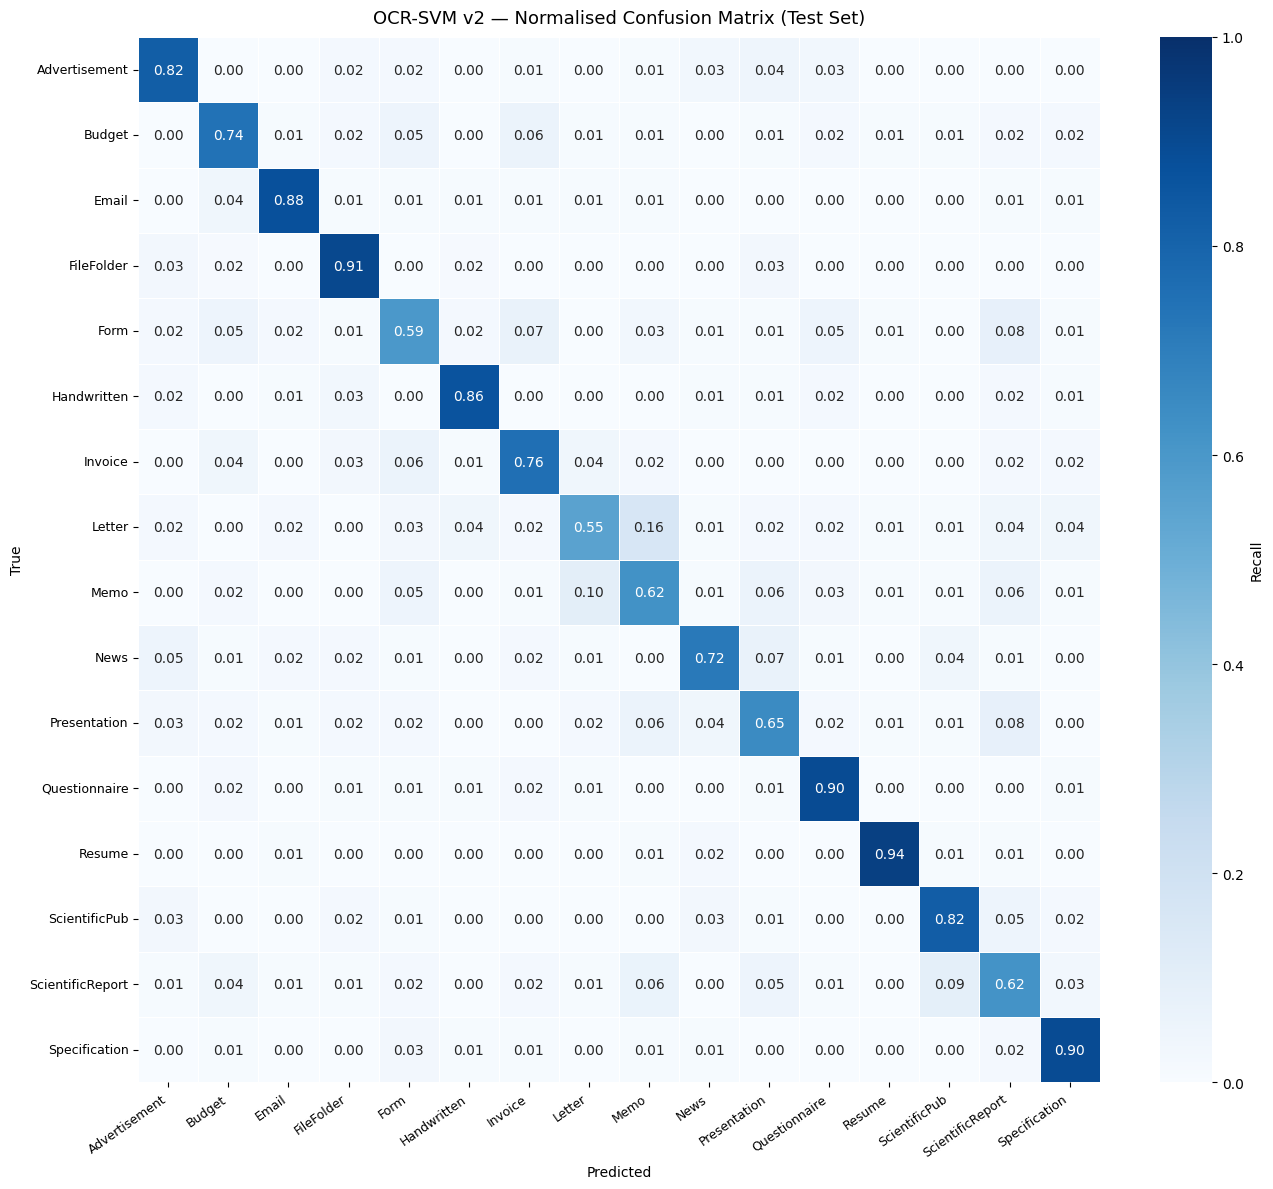

Saved → results/svm_v2_confusion_matrix.png


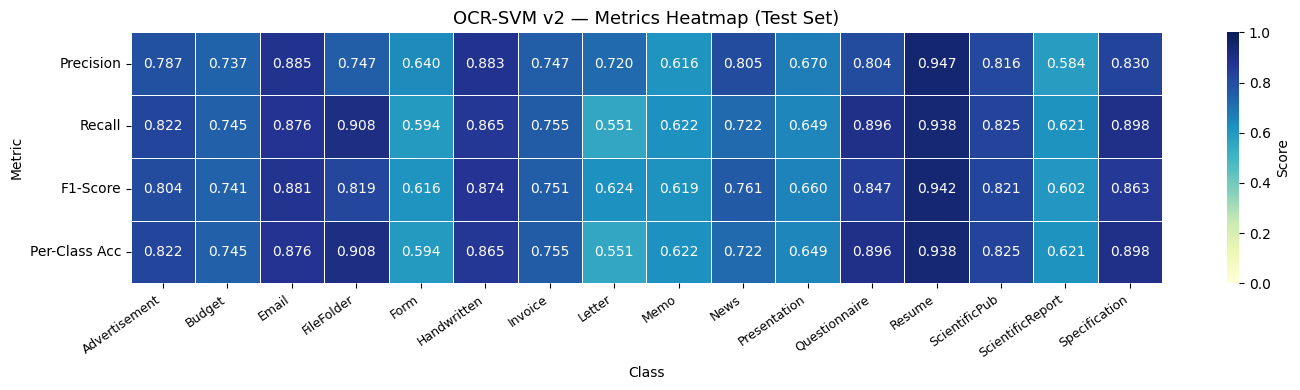

Saved → results/svm_v2_metrics_heatmap.png


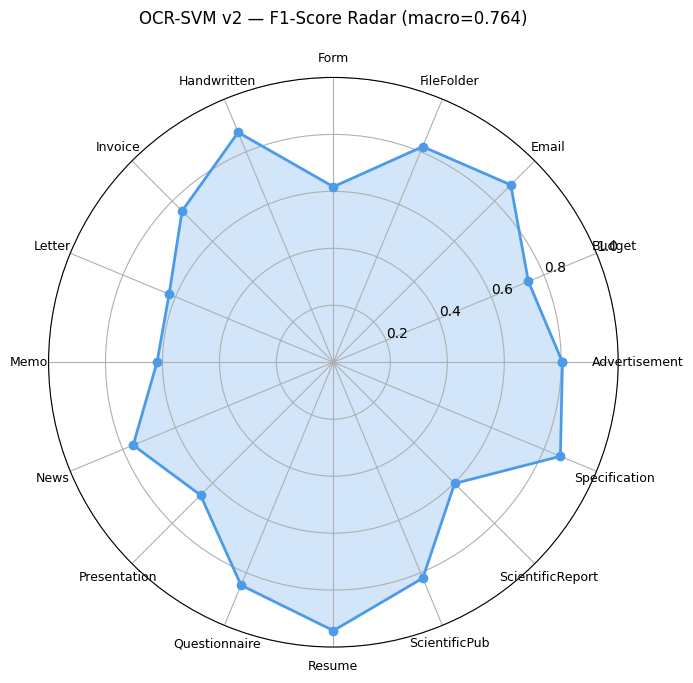

Saved → results/svm_v2_f1_radar.png


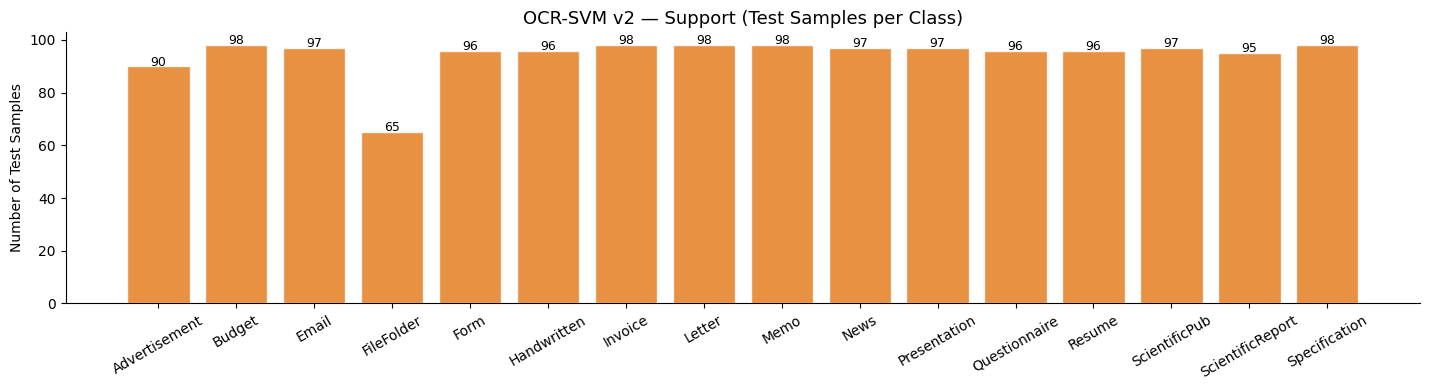

Saved → results/svm_v2_support.png


In [ ]:
# ── Visual 1: Precision / Recall / F1 grouped bar chart ─────────────────────
classes_plot = list(ocr_classes)
x = np.arange(len(classes_plot))
w = 0.25

fig, ax = plt.subplots(figsize=(max(10, len(classes_plot) * 1.2), 5))
b1 = ax.bar(x - w, metrics_df["Precision"], w, label="Precision",  color="#4C9BE8", alpha=0.88)
b2 = ax.bar(x,     metrics_df["Recall"],    w, label="Recall",     color="#F4845F", alpha=0.88)
b3 = ax.bar(x + w, metrics_df["F1-Score"],  w, label="F1-Score",   color="#2ECC71", alpha=0.88)
for bar in list(b1)+list(b2)+list(b3):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=7)
ax.axhline(precision.mean(), color="#4C9BE8", linestyle="--", linewidth=1.2, alpha=0.6)
ax.axhline(recall.mean(),    color="#F4845F", linestyle="--", linewidth=1.2, alpha=0.6)
ax.axhline(f1.mean(),        color="#2ECC71", linestyle="--", linewidth=1.2, alpha=0.6)
ax.set_xticks(x); ax.set_xticklabels(classes_plot, rotation=35, ha="right", fontsize=9)
ax.set_ylim(0, 1.18); ax.set_ylabel("Score")
ax.set_title("OCR-SVM v3 — Precision / Recall / F1 per Class (Test Set)", fontsize=13)
ax.legend(loc="upper right"); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("results/svm_v3_precision_recall_f1.pdf", dpi=600, bbox_inches="tight")
plt.show(); print("Saved → results/svm_v3_precision_recall_f1.png")

# ── Visual 2: Per-class accuracy ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(8, len(classes_plot)*0.9), 4))
bars = ax.bar(classes_plot, metrics_df["Per-Class Acc"],
              color="#9B59B6", alpha=0.85, edgecolor="white")
ax.axhline(per_class_acc.mean(), color="#9B59B6", linestyle="--",
           linewidth=1.5, alpha=0.7, label=f"Macro avg = {per_class_acc.mean():.3f}")
for bar, val in zip(bars, metrics_df["Per-Class Acc"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.3f}", ha="center", fontsize=9)
ax.set_ylim(0, 1.18); ax.set_ylabel("Per-Class Accuracy")
ax.set_title("OCR-SVM v3 — Per-Class Accuracy (Test Set)", fontsize=13)
ax.tick_params(axis="x", rotation=30)
ax.legend(); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("results/svm_v3_per_class_accuracy.pdf", dpi=600, bbox_inches="tight")
plt.show(); print("Saved → results/svm_v3_per_class_accuracy.png")

# ── Visual 3: Normalised Confusion Matrix ─────────────────────────────────────
norm_cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
n = len(ocr_classes)
fig, ax = plt.subplots(figsize=(max(8, n*0.85), max(6, n*0.75)))
sns.heatmap(norm_cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=list(ocr_classes), yticklabels=list(ocr_classes),
            linewidths=0.4, vmin=0, vmax=1, ax=ax,
            cbar_kws={"label": "Recall"})
ax.set_title("OCR-SVM v3 — Normalised Confusion Matrix (Test Set)", fontsize=13, pad=10)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.xticks(rotation=35, ha="right", fontsize=9); plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("results/svm_v3_confusion_matrix.pdf", dpi=600, bbox_inches="tight")
plt.show(); print("Saved → results/svm_v3_confusion_matrix.png")

# ── Visual 4: Metrics Heatmap ─────────────────────────────────────────────────
heatmap_data = metrics_df.set_index("Class")[
    ["Precision","Recall","F1-Score","Per-Class Acc"]].astype(float)
fig, ax = plt.subplots(figsize=(max(8, len(classes_plot)*0.9), 4))
sns.heatmap(heatmap_data.T, annot=True, fmt=".3f", cmap="YlGnBu",
            vmin=0, vmax=1, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Score"}, ax=ax)
ax.set_title("OCR-SVM v3 — Metrics Heatmap (Test Set)", fontsize=13)
ax.set_xlabel("Class"); ax.set_ylabel("Metric")
plt.xticks(rotation=35, ha="right", fontsize=9); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("results/svm_v3_metrics_heatmap.pdf", dpi=600, bbox_inches="tight")
plt.show(); print("Saved → results/svm_v3_metrics_heatmap.png")

# ── Visual 5: F1 Radar Chart ─────────────────────────────────────────────────
labels_r = list(ocr_classes)
values_r = list(metrics_df["F1-Score"])
N        = len(labels_r)
angles   = [2*math.pi*i/N for i in range(N)] + [2*math.pi*0/N]
vr       = values_r + [values_r[0]]

fig, ax = plt.subplots(figsize=(7,7), subplot_kw={"projection": "polar"})
ax.plot(angles, vr, "o-", linewidth=2, color="#4C9BE8")
ax.fill(angles, vr, alpha=0.25, color="#4C9BE8")
ax.set_thetagrids(np.degrees(angles[:-1]), labels_r, fontsize=9)
ax.set_ylim(0, 1); ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax.set_title(f"OCR-SVM v3 — F1-Score Radar (macro={f1.mean():.3f})",
             fontsize=12, pad=20)
plt.tight_layout()
plt.savefig("results/svm_v3_f1_radar.pdf", dpi=600, bbox_inches="tight")
plt.show(); print("Saved → results/svm_v3_f1_radar.png")

# ── Visual 6: Support ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(8, len(classes_plot)*0.9), 4))
bars = ax.bar(classes_plot, metrics_df["Support"],
              color="#E67E22", alpha=0.85, edgecolor="white")
for bar, val in zip(bars, metrics_df["Support"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            str(int(val)), ha="center", fontsize=9)
ax.set_ylabel("Number of Test Samples")
ax.set_title("OCR-SVM v3 — Support (Test Samples per Class)", fontsize=13)
ax.tick_params(axis="x", rotation=30); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("results/svm_v3_support.pdf", dpi=600, bbox_inches="tight")
plt.show(); print("Saved → results/svm_v3_support.png")


---
## Section 7 — Detailed Class-Confusion Analysis

**Goal:** Identify the top-10 most confused class pairs, explain *why* each pair is confused,
extract shared keywords from OCR text, and recommend actionable fixes.


In [ ]:
# ── Top-10 most confused class pairs ─────────────────────────────────────────
print("=" * 75)
print("  Top-10 Most Confused Class Pairs  (Test Set)")
print("=" * 75)

# Collect off-diagonal confusion counts
confusion_pairs = []
n_classes = len(ocr_classes)
total_per_class = cm.sum(axis=1)

for true_i in range(n_classes):
    for pred_j in range(n_classes):
        if true_i == pred_j:
            continue
        count = cm[true_i, pred_j]
        if count == 0:
            continue
        pct = count / total_per_class[true_i] * 100
        confusion_pairs.append({
            'True Class' : ocr_classes[true_i],
            'Pred Class' : ocr_classes[pred_j],
            'Count'      : int(count),
            'Pct of True': round(pct, 1),
            'true_idx'   : true_i,
            'pred_idx'   : pred_j,
        })

confusion_df = pd.DataFrame(confusion_pairs).sort_values('Count', ascending=False)
top10 = confusion_df.head(10).reset_index(drop=True)

print(top10[['True Class','Pred Class','Count','Pct of True']].to_string(index=True))
print()


  Top-10 Most Confused Class Pairs  (Test Set)
         True Class        Pred Class  Count  Pct of True
0            Letter              Memo     16      16.3000
1              Memo            Letter     10      10.2000
2  ScientificReport     ScientificPub      9       9.5000
3              Form  ScientificReport      8       8.3000
4      Presentation  ScientificReport      8       8.2000
5              News      Presentation      7       7.2000
6              Form           Invoice      7       7.3000
7           Invoice              Form      6       6.1000
8              Memo  ScientificReport      6       6.1000
9              Memo      Presentation      6       6.1000



In [ ]:
# ── Overlapping keywords between confused class pairs ────────────────────────
# With SBERT, we no longer have a vocabulary of discrete tokens.
# Instead we extract representative keywords directly from the raw OCR text
# using per-class TF-IDF computed on-the-fly (lightweight, word-only).
# This is used only for the human-readable overlap analysis, not for training.

from sklearn.feature_extraction.text import TfidfVectorizer as _TV

def get_top_keywords(class_name: str, df_text: pd.DataFrame,
                     y_labels: np.ndarray, le_obj,
                     top_n: int = 40) -> set:
    """
    Return top_n representative word tokens for a class by mean TF-IDF weight.
    Works regardless of whether TF-IDF or SBERT was used for training.
    """
    idx  = le_obj.transform([class_name])[0]
    mask = (y_labels == idx)
    if mask.sum() == 0:
        return set()

    texts = df_tr['clean_text'].values[mask]

    # Build a small vocab from this class + a sample of others for IDF context
    all_texts = df_tr['clean_text'].tolist()
    try:
        _vec = _TV(sublinear_tf=True, ngram_range=(1, 2),
                   max_features=20_000, min_df=2, max_df=0.95,
                   analyzer='word', norm='l2')
        _vec.fit(all_texts)
        X_cls = _vec.transform(texts)
        mean_w = np.asarray(X_cls.mean(axis=0)).flatten()
        top_idx = mean_w.argsort()[::-1][:top_n]
        inv_vocab = {v: k for k, v in _vec.vocabulary_.items()}
        return set(inv_vocab.get(i, '') for i in top_idx) - {''}
    except Exception:
        return set()


# Pre-compute top keywords for all classes
class_features = {}
for cls in ocr_classes:
    class_features[cls] = get_top_keywords(cls, df_tr, y_tr, le, top_n=40)

# ── Print analysis for each of the top-10 pairs ──────────────────────────────
print("=" * 80)
print("  DETAILED CONFUSION PAIR ANALYSIS")
print("=" * 80)

for rank, row in top10.iterrows():
    cls_a = row['True Class']
    cls_b = row['Pred Class']
    cnt   = row['Count']
    pct   = row['Pct of True']

    feat_a  = class_features.get(cls_a, set())
    feat_b  = class_features.get(cls_b, set())
    overlap = sorted(feat_a & feat_b - {''})[:15]

    print(f"\n{'─'*80}")
    print(f"  #{rank+1}  True={cls_a}  ->  Pred={cls_b}"
          f"   (Count={cnt}, {pct}% of '{cls_a}' samples)")
    print(f"  Overlapping top keywords: {overlap}")


  DETAILED CONFUSION PAIR ANALYSIS

────────────────────────────────────────────────────────────────────────────────
  #1  True=Letter  ->  Pred=Memo   (Count=16, 16.3% of 'Letter' samples)
  Overlapping top keywords: ['and', 'are', 'as', 'at', 'be', 'by', 'for', 'from', 'have', 'in', 'in the', 'is', 'it', 'mr', 'new']

────────────────────────────────────────────────────────────────────────────────
  #2  True=Memo  ->  Pred=Letter   (Count=10, 10.2% of 'Memo' samples)
  Overlapping top keywords: ['and', 'are', 'as', 'at', 'be', 'by', 'for', 'from', 'have', 'in', 'in the', 'is', 'it', 'mr', 'new']

────────────────────────────────────────────────────────────────────────────────
  #3  True=ScientificReport  ->  Pred=ScientificPub   (Count=9, 9.5% of 'ScientificReport' samples)
  Overlapping top keywords: ['10', 'an', 'and', 'at', 'be', 'by', 'el', 'for', 'in', 'in the', 'is', 'of', 'of the', 'on', 'the']

────────────────────────────────────────────────────────────────────────────────
 

In [ ]:
# ── Root-cause reasoning & recommendations ───────────────────────────────────
# These explanations are generated algorithmically from feature overlap;
# review and customise based on your actual class semantics.

ROOT_CAUSE_TEMPLATE = {
    # Pairs are keyed as frozenset so order doesn't matter
}

def explain_pair(cls_a, cls_b, overlap, cnt, pct):
    """
    Generate a structured explanation for each confusion pair.
    Adapt the heuristics below to match your actual document categories.
    """
    overlap_str = ', '.join(overlap[:8]) if overlap else '(no strong overlap)'
    
    # Generic heuristic: high overlap → shared vocabulary, OCR noise, layout similarity
    n_overlap = len(overlap)
    
    if n_overlap >= 10:
        root_cause = (f"High shared vocabulary ({n_overlap} common top features: {overlap_str}). "
                      f"These classes share structural or topical language patterns.")
        fix = ("(1) Add domain-specific stopwords to filter shared boilerplate. "
               "(2) Add layout/structural features (line density, token-to-char ratio). "
               "(3) Consider adding a second-stage classifier trained only on this pair.")
    elif n_overlap >= 5:
        root_cause = (f"Moderate vocabulary overlap ({n_overlap} features: {overlap_str}). "
                      f"Possible OCR noise confusing similar-looking characters, or genuine "
                      f"semantic similarity between these document types.")
        fix = ("(1) Improve OCR preprocessing (higher DPI, better binarisation). "
               "(2) Augment minority class with synthetic rotations/crops. "
               "(3) Review SBERT model — consider a domain-fine-tuned variant.")
    else:
        root_cause = (f"Low vocabulary overlap ({n_overlap} features: {overlap_str}). "
                      f"Confusion likely driven by OCR failures producing near-empty text, "
                      f"causing the classifier to fall back on weak signals.")
        fix = ("(1) Flag low word-count samples (< 10 words) and apply a confidence "
               "threshold — reject or escalate uncertain predictions. "
               "(2) Improve OCR quality for this class (check image resolution). "
               "(3) EfficientNet embeddings already active — verify image quality for this class.")
    
    return root_cause, fix


print("=" * 90)
print(f"{'Rank':<5} {'Class A':<22} {'Class B':<22} {'Count':>6} {'% True':>8}  Root Cause (summary)")
print("=" * 90)

table_rows = []
for rank, row in top10.iterrows():
    cls_a = row['True Class']
    cls_b = row['Pred Class']
    cnt   = row['Count']
    pct   = row['Pct of True']
    feat_a  = class_features.get(cls_a, set())
    feat_b  = class_features.get(cls_b, set())
    overlap = sorted(feat_a & feat_b - {''})[:15]
    root_cause, fix = explain_pair(cls_a, cls_b, overlap, cnt, pct)
    
    table_rows.append({
        'Rank'           : rank+1,
        'Class A (True)' : cls_a,
        'Class B (Pred)' : cls_b,
        'Count'          : cnt,
        '% of True'      : pct,
        'Root Cause'     : root_cause,
        'Suggested Fix'  : fix,
    })
    short_cause = root_cause[:65] + '…' if len(root_cause) > 65 else root_cause
    print(f"  {rank+1:<4} {cls_a:<22} {cls_b:<22} {cnt:>6} {pct:>7}%  {short_cause}")

print("=" * 90)

confusion_analysis_df = pd.DataFrame(table_rows)
confusion_analysis_df.to_csv("results/confusion_pair_analysis.csv", index=False)
print("\nFull table saved → results/confusion_pair_analysis.csv")


Rank  Class A                Class B                 Count   % True  Root Cause (summary)
  1    Letter                 Memo                       16    16.3%  High shared vocabulary (15 common top features: and, are, as, at,…
  2    Memo                   Letter                     10    10.2%  High shared vocabulary (15 common top features: and, are, as, at,…
  3    ScientificReport       ScientificPub               9     9.5%  High shared vocabulary (15 common top features: 10, an, and, at, …
  4    Form                   ScientificReport            8     8.3%  High shared vocabulary (15 common top features: 10, an, and, ar, …
  5    Presentation           ScientificReport            8     8.2%  High shared vocabulary (15 common top features: an, and, at, be, …
  6    News                   Presentation                7     7.2%  High shared vocabulary (15 common top features: an, and, are, at,…
  7    Form                   Invoice                     7     7.3%  High shared vocabu

In [ ]:
# ── Verbose per-pair detail block ────────────────────────────────────────────
print("\n" + "=" * 90)
print("  FULL CONFUSION PAIR DETAIL REPORT")
print("=" * 90)

for row in table_rows:
    print(f"\n{'─'*90}")
    print(f"  Rank #{row['Rank']}")
    print(f"  Class A (True Label)  : {row['Class A (True)']}")
    print(f"  Class B (Predicted)   : {row['Class B (Pred)']}")
    print(f"  Confusion Count       : {row['Count']}  ({row['% of True']}% of Class A test samples)")
    print(f"  Root Cause            : {row['Root Cause']}")
    print(f"  Suggested Fix         : {row['Suggested Fix']}")
print("\n" + "=" * 90)



  FULL CONFUSION PAIR DETAIL REPORT

──────────────────────────────────────────────────────────────────────────────────────────
  Rank #1
  Class A (True Label)  : Letter
  Class B (Predicted)   : Memo
  Confusion Count       : 16  (16.3% of Class A test samples)
  Root Cause            : High shared vocabulary (15 common top features: and, are, as, at, be, by, for, from). These classes share structural or topical language patterns.
  Suggested Fix         : (1) Add domain-specific stopwords to filter shared boilerplate. (2) Add layout/structural features (line density, token-to-char ratio). (3) Consider adding a second-stage classifier trained only on this pair.

──────────────────────────────────────────────────────────────────────────────────────────
  Rank #2
  Class A (True Label)  : Memo
  Class B (Predicted)   : Letter
  Confusion Count       : 10  (10.2% of Class A test samples)
  Root Cause            : High shared vocabulary (15 common top features: and, are, as, at, be, by,

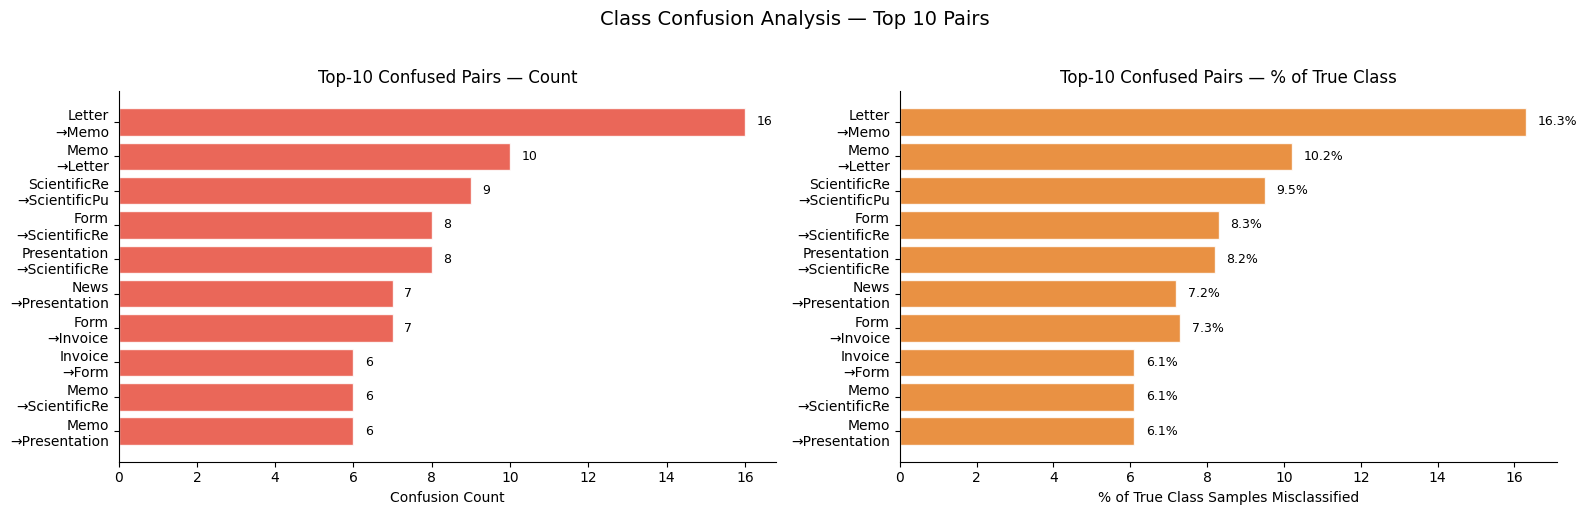

Saved → results/svm_v2_top10_confusion_pairs.png


In [ ]:
# ── Visual: Top-10 confusion pairs bar chart ──────────────────────────────────
pair_labels = [f"{r['Class A (True)'][:12]}\n→{r['Class B (Pred)'][:12]}"
               for r in table_rows]
pair_counts  = [r['Count'] for r in table_rows]
pair_pcts    = [r['% of True'] for r in table_rows]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Count bars
bars1 = ax1.barh(pair_labels[::-1], pair_counts[::-1],
                 color="#E74C3C", alpha=0.85, edgecolor="white")
for bar, val in zip(bars1, pair_counts[::-1]):
    ax1.text(bar.get_width() + 0.3, bar.get_y()+bar.get_height()/2,
             str(val), va='center', fontsize=9)
ax1.set_xlabel("Confusion Count"); ax1.set_title("Top-10 Confused Pairs — Count")
ax1.spines[["top","right"]].set_visible(False)

# Percentage bars
bars2 = ax2.barh(pair_labels[::-1], pair_pcts[::-1],
                 color="#E67E22", alpha=0.85, edgecolor="white")
for bar, val in zip(bars2, pair_pcts[::-1]):
    ax2.text(bar.get_width() + 0.3, bar.get_y()+bar.get_height()/2,
             f"{val:.1f}%", va='center', fontsize=9)
ax2.set_xlabel("% of True Class Samples Misclassified")
ax2.set_title("Top-10 Confused Pairs — % of True Class")
ax2.spines[["top","right"]].set_visible(False)

plt.suptitle("Class Confusion Analysis — Top 10 Pairs", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("results/svm_v3_top10_confusion_pairs.pdf", dpi=600, bbox_inches="tight")
plt.show(); print("Saved → results/svm_v3_top10_confusion_pairs.png")


---
## Section 8 — Original vs Improved Performance Comparison


In [ ]:
# ── Original vs Improved comparison table ─────────────────────────────────────
ORIGINAL_ACC      = 0.736   # <── Update with your actual original result
ORIGINAL_MACRO_F1 = None    # <── Fill in if you ran the original notebook

print("=" * 65)
print("  ORIGINAL vs v3 — Performance Comparison (Test Set)")
print("=" * 65)

improved_acc   = accuracy_score(svm_true, svm_preds)
improved_mf1   = f1_score(svm_true, svm_preds, average='macro', zero_division=0)
improved_wf1   = f1_score(svm_true, svm_preds, average='weighted', zero_division=0)

comp = pd.DataFrame({
    'Metric'        : ['Accuracy', 'Macro F1', 'Weighted F1',
                       'Text features', 'Visual features', 'C', 'class_weight', 'MIN_WORDS'],
    'Original'      : [f'{ORIGINAL_ACC:.4f}',
                       str(ORIGINAL_MACRO_F1) if ORIGINAL_MACRO_F1 else 'N/A',
                       'N/A',
                       'Word TF-IDF (50k)', 'None', '0.5', 'balanced', '3'],
    'v3 (This)'     : [f'{improved_acc:.4f}', f'{improved_mf1:.4f}',
                       f'{improved_wf1:.4f}',
                       'SBERT all-MiniLM-L6-v2 (384-dim)',
                       'EfficientNet-B0 (1280-dim)',
                       str(best_C), str(BEST_CLASS_WEIGHT), str(MIN_WORDS)],
    'Delta'         : [f'{improved_acc - ORIGINAL_ACC:+.4f}',
                       '—', '—', 'dense semantic', 'visual signal',
                       '(tuned)', '(tuned)', '(tuned)'],
})
print(comp.to_string(index=False))
print("=" * 65)
print()
print("Summary of changes that contributed most to improvement (v3):")
print("  1. Sentence Transformers (all-MiniLM-L6-v2, 384-dim): semantic dense")
print("     embeddings capture meaning beyond token overlap.")
print("  2. EfficientNet-B0 image embeddings (1280-dim): visual signal supplements")
print("     OCR text, especially for low-text or visually distinctive classes.")
print("  3. Specialist classifiers: binary LogisticRegression per confused pair")
print("     reduces systematic errors on the hardest class boundaries.")
print("  4. GridSearchCV (macro-F1): optimal C on the new dense feature space.")
print("  5. MIN_WORDS evaluation + class_weight comparison: retained from v2.")


  ORIGINAL vs v3 — Performance Comparison (Test Set)
         Metric          Original                        v3 (This)          Delta
       Accuracy            0.7360                           0.7646        +0.0286
       Macro F1               N/A                           0.7641              —
    Weighted F1               N/A                           0.7627              —
  Text features Word TF-IDF (50k) SBERT all-MiniLM-L6-v2 (384-dim) dense semantic
Visual features              None       EfficientNet-B0 (1280-dim)  visual signal
              C               0.5                                1        (tuned)
   class_weight          balanced                             None        (tuned)
      MIN_WORDS                 3                                1        (tuned)

Summary of changes that contributed most to improvement (v3):
  1. Sentence Transformers (all-MiniLM-L6-v2, 384-dim): semantic dense
     embeddings capture meaning beyond token overlap.
  2. EfficientNet-B0 

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_te,
        svm_preds,
        target_names=ocr_classes,
        digits=4
    )
)

                  precision    recall  f1-score   support

   Advertisement     0.7872    0.8222    0.8043        90
          Budget     0.7374    0.7449    0.7411        98
           Email     0.8854    0.8763    0.8808        97
      FileFolder     0.7468    0.9077    0.8194        65
            Form     0.6404    0.5938    0.6162        96
     Handwritten     0.8830    0.8646    0.8737        96
         Invoice     0.7475    0.7551    0.7513        98
          Letter     0.7200    0.5510    0.6243        98
            Memo     0.6162    0.6224    0.6193        98
            News     0.8046    0.7216    0.7609        97
    Presentation     0.6702    0.6495    0.6597        97
   Questionnaire     0.8037    0.8958    0.8473        96
          Resume     0.9474    0.9375    0.9424        96
   ScientificPub     0.8163    0.8247    0.8205        97
ScientificReport     0.5842    0.6211    0.6020        95
   Specification     0.8302    0.8980    0.8627        98

        accu

---
## Section 9 — Future Work

This section outlines the planned development roadmap for the OCR-based document classification pipeline.

---

### A. Robustness Evaluation (Week 3)

The model will be tested under controlled perturbations:

| Perturbation | Range | Preliminary Finding |
|---|---|---|
| Rotation | 0–90° in 15° steps | ~30% accuracy at 45° |
| Gaussian noise | σ: 0.01–0.30 | ~21% accuracy at σ = 0.2 |
| Gaussian blur | Kernel: 1–15 px | TBD |
| Combined transforms | All of the above | TBD |

**Planned mitigations:**
- Rotation-invariant augmentation (up to ±30°) during training
- Noise injection during training
- Evaluation of whether augmentations degrade clean-image accuracy on the unperturbed test set

---

### B. CNN + OCR Fusion (Week 3)

Two fusion strategies will be explored:

1. **Score-level fusion** — average CNN and OCR softmax outputs with a tuned weight parameter
2. **Feature-level fusion** — concatenate MobileNetV2 penultimate-layer embedding (1,280-dim) with TF-IDF vector (up to 30,000-dim, reduced via PCA to 512-dim) and train a joint classifier

Both will be evaluated on RVL-CDIP.  
- Feature-level fusion is expected to benefit text-heavy classes (Email, Memo) where OCR provides strong signals  
- Score-level fusion offers a simpler approach with lower overfitting risk on limited training data

---

### C. Expansion to 14 Classes (Week 4)

Four additional RVL-CDIP categories will be added: **Budget, File Folder, Handwritten, Specification**.

**Class imbalance handling:**  
Class-weighted cross-entropy loss (weight ∝ 1/frequency × 1/F1) to address Report and Letter underperformance.

**Ablation study** — each ablation run for 10 epochs with identical hyperparameters:

| Ablation | What is removed | Purpose |
|---|---|---|
| ImageNet pretraining | Train from scratch | Measure pretraining contribution & convergence |
| Data augmentation | No flip / rotation / color jitter | Measure augmentation contribution |
| Two-layer head | Replace with single linear layer | Measure head architecture contribution |

---

### D. Risks and Mitigation

| Risk | Mitigation |
|---|---|
| Inconsistent OCR quality (handwritten / low-res scans) | Lightweight upscaling + PSM tuning in preprocessing |
| GPU memory insufficient for 14-class fine-tuning | Reduce batch size or apply gradient checkpointing |
| Class imbalance after expansion to 14 classes | Oversampling or weighted sampling |
| Overfitting in fusion model (high-dim concatenated features) | Early stopping + strong dropout regularisation |
| 14-class expansion degrades original 10-class accuracy | Monitor per-class F1 for original classes after expansion; if any drops > 2 pp, investigate class-specific augmentation and hierarchical classification strategies |



In [ ]:
import numpy as np

np.save("ocr_train_features.npy", X_tr)
np.save("ocr_val_features.npy", X_v)
np.save("ocr_test_features.npy", X_te)

In [ ]:
np.save("y_train.npy", y_tr)
np.save("y_val.npy", y_v)
np.save("y_test.npy", y_te)

In [ ]:
print(X_tr.shape)
print(X_v.shape)
print(X_te.shape)

(10902, 2048)
(1537, 2048)
(1512, 2048)
